# Autoencoder Trained on MNIST

A PyTorch flavor of the code at From https://towardsdatascience.com/auto-encoder-what-is-it-and-what-is-it-used-for-part-1-3e5c6f017726/ and
https://gist.github.com/wmlba/ed6448da9dce3a3c0f6ee78e972dd07b#file-autoencoder_feedforward-py.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DL4DS/sp2026/blob/main/lecture_collateral/vae/01_autoencoder_mnist.ipynb)


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random
import os


In [3]:
# Create data directory if it doesn't exist
os.makedirs('./data', exist_ok=True)

In [4]:
# Define the Autoencoder architecture
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 512),
            nn.ELU(),
            nn.Linear(512, 128),
            nn.ELU(),
            nn.Linear(128, 10),  # bottleneck
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(10, 128),
            nn.ELU(),
            nn.Linear(128, 512),
            nn.ELU(),
            nn.Linear(512, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)


In [5]:

# Set device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
#    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)


Using device: mps


100.0%
100.0%
100.0%
100.0%

Training dataset size: 60000
Test dataset size: 10000


In [6]:

# Training loop
def train(model, optimizer, criterion, epochs):
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.view(data.size(0), -1).to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, data)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
        print(f'Epoch: {epoch+1}, Average Loss: {train_loss / len(train_loader):.4f}')


In [7]:
# Get encoded representations and reconstructions
def get_representations(loader, model):
    model.eval()
    encoded_data = []
    decoded_data = []
    original_data = []
    with torch.no_grad():
        for data, _ in loader:
            data = data.view(data.size(0), -1).to(device)
            encoded = model.encode(data)
            decoded = model.decode(encoded)
            encoded_data.append(encoded)
            decoded_data.append(decoded)
            original_data.append(data)
    return torch.cat(encoded_data), torch.cat(decoded_data), torch.cat(original_data)


In [8]:
def visualize_results(original, reconstructed, n=10):
    try:
        # If we're given single images, convert them to batch format
        if len(original.shape) == 1:
            original = original.unsqueeze(0)
        if len(reconstructed.shape) == 1:
            reconstructed = reconstructed.unsqueeze(0)
        
        # Randomly select n indices if we have more than n samples
        if original.shape[0] > n:
            indices = random.sample(range(original.shape[0]), n)
        else:
            indices = range(original.shape[0])
            n = len(indices)
        
        plt.figure(figsize=(20, 4))
        for i, idx in enumerate(indices):
            # Original
            ax = plt.subplot(2, n, i + 1)
            plt.imshow(original[idx].detach().cpu().reshape(28, 28).numpy())
            plt.gray()
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)
            
            # Reconstructed
            ax = plt.subplot(2, n, i + 1 + n)
            plt.imshow(reconstructed[idx].detach().cpu().reshape(28, 28).numpy())
            plt.gray()
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)
        plt.show()
    except Exception as e:
        print(f"Error in visualization: {str(e)}")
        print(f"Original shape: {original.shape}")
        print(f"Reconstructed shape: {reconstructed.shape}")

In [9]:

# Initialize model, loss function and optimizer
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())


In [10]:
# Train the model
print("Training the model...")
train(model, optimizer, criterion, epochs=10)
print("Training completed!")

Training the model...
Epoch: 1, Average Loss: 0.0799
Epoch: 2, Average Loss: 0.0517
Epoch: 3, Average Loss: 0.0381
Epoch: 4, Average Loss: 0.0312
Epoch: 5, Average Loss: 0.0273
Epoch: 6, Average Loss: 0.0247
Epoch: 7, Average Loss: 0.0228
Epoch: 8, Average Loss: 0.0212
Epoch: 9, Average Loss: 0.0201
Epoch: 10, Average Loss: 0.0193
Training completed!


In [11]:
# Get encoded and decoded data
print("Getting representations...")
encoded_data, decoded_output, original_data = get_representations(train_loader, model)
print(f"Encoded data shape: {encoded_data.shape}")
print(f"Decoded output shape: {decoded_output.shape}")
print(f"Original data shape: {original_data.shape}")

Getting representations...
Encoded data shape: torch.Size([60000, 10])
Decoded output shape: torch.Size([60000, 784])
Original data shape: torch.Size([60000, 784])


## Reconstruct from Training Set

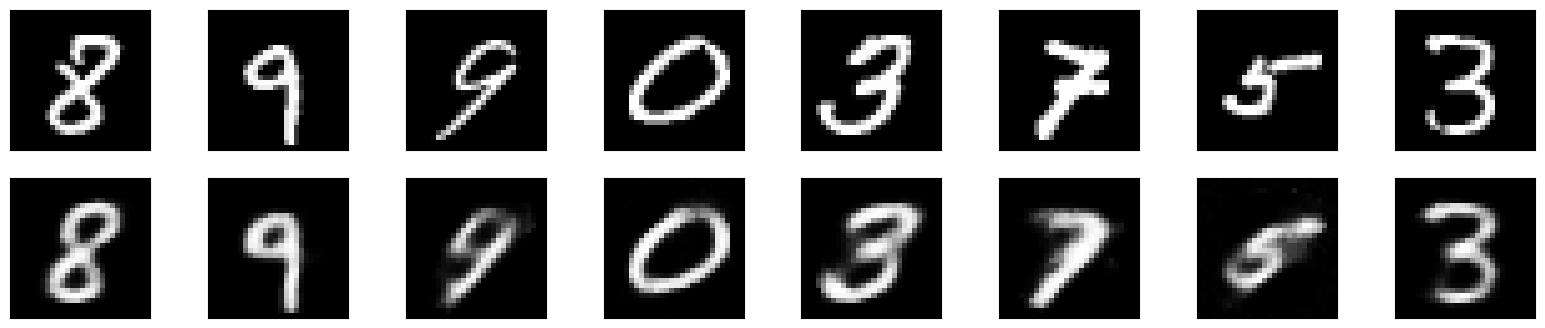

In [12]:
# Example usage for multiple images
indices = random.sample(range(len(train_dataset)), 10)
original_imgs = torch.stack([train_dataset[idx][0].view(-1) for idx in indices])
decoded_imgs = model(original_imgs.to(device)).cpu()

# Visualize multiple image comparisons
visualize_results(original_imgs, decoded_imgs, n=8)

## Evaluate on Test Set

In [13]:
# Evaluate loss on test set
model.eval()
test_loss = 0
with torch.no_grad():
    for data, _ in test_loader:
        data = data.view(data.size(0), -1).to(device)
        output = model(data)
        loss = criterion(output, data)
        test_loss += loss.item()
avg_test_loss = test_loss / len(test_loader)

# For comparison, also compute loss on training set (since training loss wasn't stored)
model.eval()
train_loss = 0
with torch.no_grad():
    for data, _ in train_loader:
        data = data.view(data.size(0), -1).to(device)
        output = model(data)
        loss = criterion(output, data)
        train_loss += loss.item()
avg_train_loss = train_loss / len(train_loader)

print(f'Average Training Loss: {avg_train_loss:.4f}')
print(f'Average Test Loss: {avg_test_loss:.4f}')
print(f'Test loss is {"higher" if avg_test_loss > avg_train_loss else "lower"} than training loss.')

Average Training Loss: 0.0189
Average Test Loss: 0.0187
Test loss is lower than training loss.


## Reconstruct from Test Set

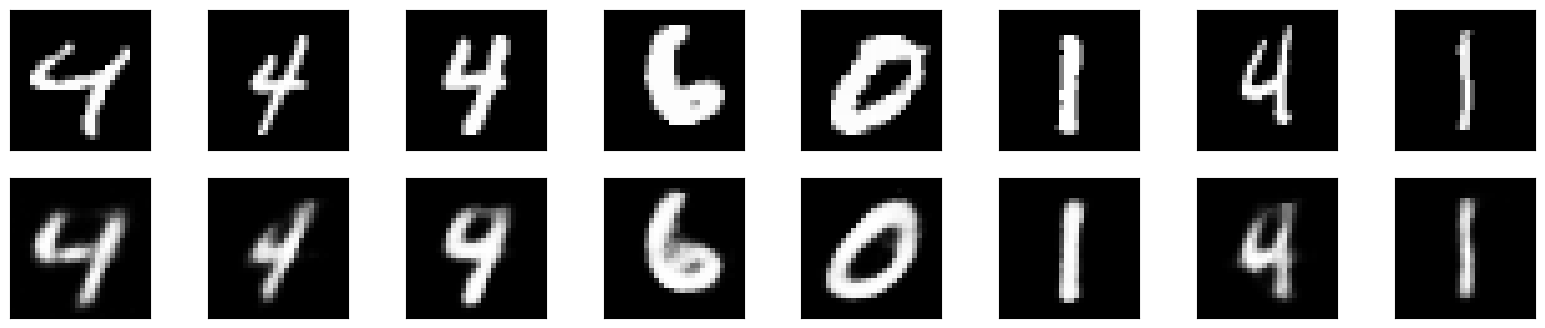

In [44]:
# Example usage for multiple images
test_indices = random.sample(range(len(test_dataset)), 10)
original_imgs = torch.stack([test_dataset[idx][0].view(-1) for idx in test_indices])
test_decoded_imgs = model(original_imgs.to(device)).cpu()

# Visualize multiple image comparisons
visualize_results(original_imgs, test_decoded_imgs, n=8)

## Decode Samples from a Fixed Gaussian Prior

Sample latent vectors from a standard-ish Gaussian (fixed mean/variance, *not* the
per-dim training statistics) and decode them. Because a plain autoencoder makes no
effort to shape the latent distribution, samples from an arbitrary prior usually
land in empty regions of latent space and decode to garbage — motivating the VAE.

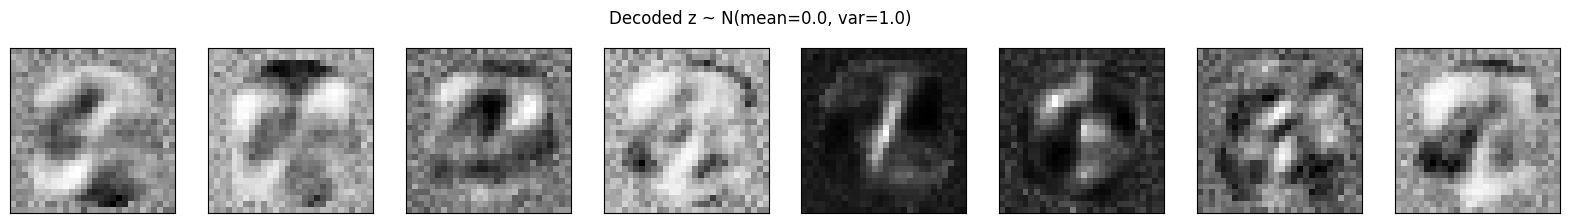

In [36]:
# Sample 8 latent vectors from a Gaussian with a fixed mean and variance, decode, and plot
fixed_mean = 0.0
fixed_var = 1.0
n_samples = 8
latent_dim = 10

model.eval()
with torch.no_grad():
    z = torch.randn(n_samples, latent_dim, device=device) * (fixed_var ** 0.5) + fixed_mean
    generated = model.decode(z).cpu()

plt.figure(figsize=(20, 2.5))
for i in range(n_samples):
    ax = plt.subplot(1, n_samples, i + 1)
    plt.imshow(generated[i].reshape(28, 28).numpy(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.suptitle(f"Decoded z ~ N(mean={fixed_mean}, var={fixed_var})")
plt.show()

## Sample a latent vector from training stats

Gather statistics on the latent vectors of the training images and the sample from a multivariate gaussian with those statistics.

In [15]:
# Compute per-dimension mean and variance of latent vectors over the training set
latent_mean = encoded_data.mean(dim=0)
latent_std = encoded_data.std(dim=0)
print(f"Latent mean: {latent_mean.cpu().numpy()}")
print(f"Latent std:  {latent_std.cpu().numpy()}")

Latent mean: [ -4.54685   -18.099825  -10.198232  -24.088188  -13.516976   13.426243
  11.387987    8.242942   -5.3593006 -11.220161 ]
Latent std:  [ 8.583122   9.356948  10.085624  10.749437   9.462485   8.422824
  7.2633967  8.22837    6.4932995  9.072654 ]


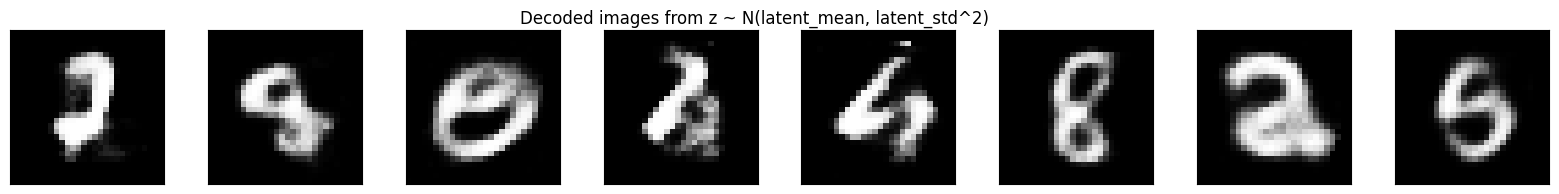

In [30]:
# Sample latent vectors from a Gaussian with the per-dimension training mean/std,
# decode them, and visualize the generated images
n_samples = 8
model.eval()
with torch.no_grad():
    z = torch.randn(n_samples, latent_mean.shape[0], device=device) * latent_std + latent_mean
    generated = model.decode(z).cpu()

plt.figure(figsize=(20, 2))
for i in range(n_samples):
    ax = plt.subplot(1, n_samples, i + 1)
    plt.imshow(generated[i].reshape(28, 28).numpy())
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.suptitle("Decoded images from z ~ N(latent_mean, latent_std^2)")
plt.show()

## Interpolate Between Two Latent Vectors

In [ ]:
# Pick two training images, encode them, and interactively linearly interpolate
# between their latent vectors, decoding at each step.
# Requires ipywidgets: `pip install ipywidgets` (Colab has it by default).
from ipywidgets import interact, FloatSlider
from IPython.display import display

model.eval()

# Pick two random training images as endpoints
idx_a, idx_b = random.sample(range(len(train_dataset)), 2)
x_a = train_dataset[idx_a][0].view(-1).to(device)
x_b = train_dataset[idx_b][0].view(-1).to(device)
label_a, label_b = train_dataset[idx_a][1], train_dataset[idx_b][1]

with torch.no_grad():
    z_a = model.encode(x_a.unsqueeze(0))
    z_b = model.encode(x_b.unsqueeze(0))

def show_interp(alpha=0.5):
    with torch.no_grad():
        z = (1 - alpha) * z_a + alpha * z_b
        x_hat = model.decode(z).cpu().reshape(28, 28).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(8, 3))
    axes[0].imshow(x_a.cpu().reshape(28, 28).numpy(), cmap='gray')
    axes[0].set_title(f"A (label {label_a}), α=0")
    axes[1].imshow(x_hat, cmap='gray')
    axes[1].set_title(f"decode((1-α)·z_A + α·z_B), α={alpha:.2f}")
    axes[2].imshow(x_b.cpu().reshape(28, 28).numpy(), cmap='gray')
    axes[2].set_title(f"B (label {label_b}), α=1")
    for ax in axes:
        ax.axis('off')
    plt.show()

interact(show_interp, alpha=FloatSlider(min=0.0, max=1.0, step=0.02, value=0.5));

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, step=0.02), Output()), _dom_classes…